# SEP 767 Final Project: Employee Attrition Analysis
## 1. Research Questions
**Segmentation → Drivers → Prediction**

**Employee Segmentation:** Do employees with and without attrition exhibit distinct patterns in multivariate feature space?

**Employee Attrition Drivers:** What factors significantly influence employee attrition?

**Employee Attrition Prediction:** Can we accurately predict whether an employee will leave based on available features?

---

## 2. Dataset
IBM HR Analytics Employee Attrition & Performance. This is a fictional data set created by IBM data scientists.

Link to the dataset: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/data

The dataset includes 35 columns and 1470 rows.

Target variable: `Attrition` 

---

## 3.  Methodology

- Employee segmentation: PCA - score plot
- Attrition drivers: PLS, coefficients, VIP scores
- Attrition Prediction: PLS-DA


In [269]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import scipy.stats as stats

In [270]:
pd.set_option('display.max_columns', None)

In [271]:
df=pd.read_csv('employee.csv')

# Exploratory Data Analysis (EDA)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [49]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Missing Values Check

In [50]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

## Duplicate Values Check

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [53]:
cat_cols = df.select_dtypes(include=["object"]).columns
len(cat_cols)

9

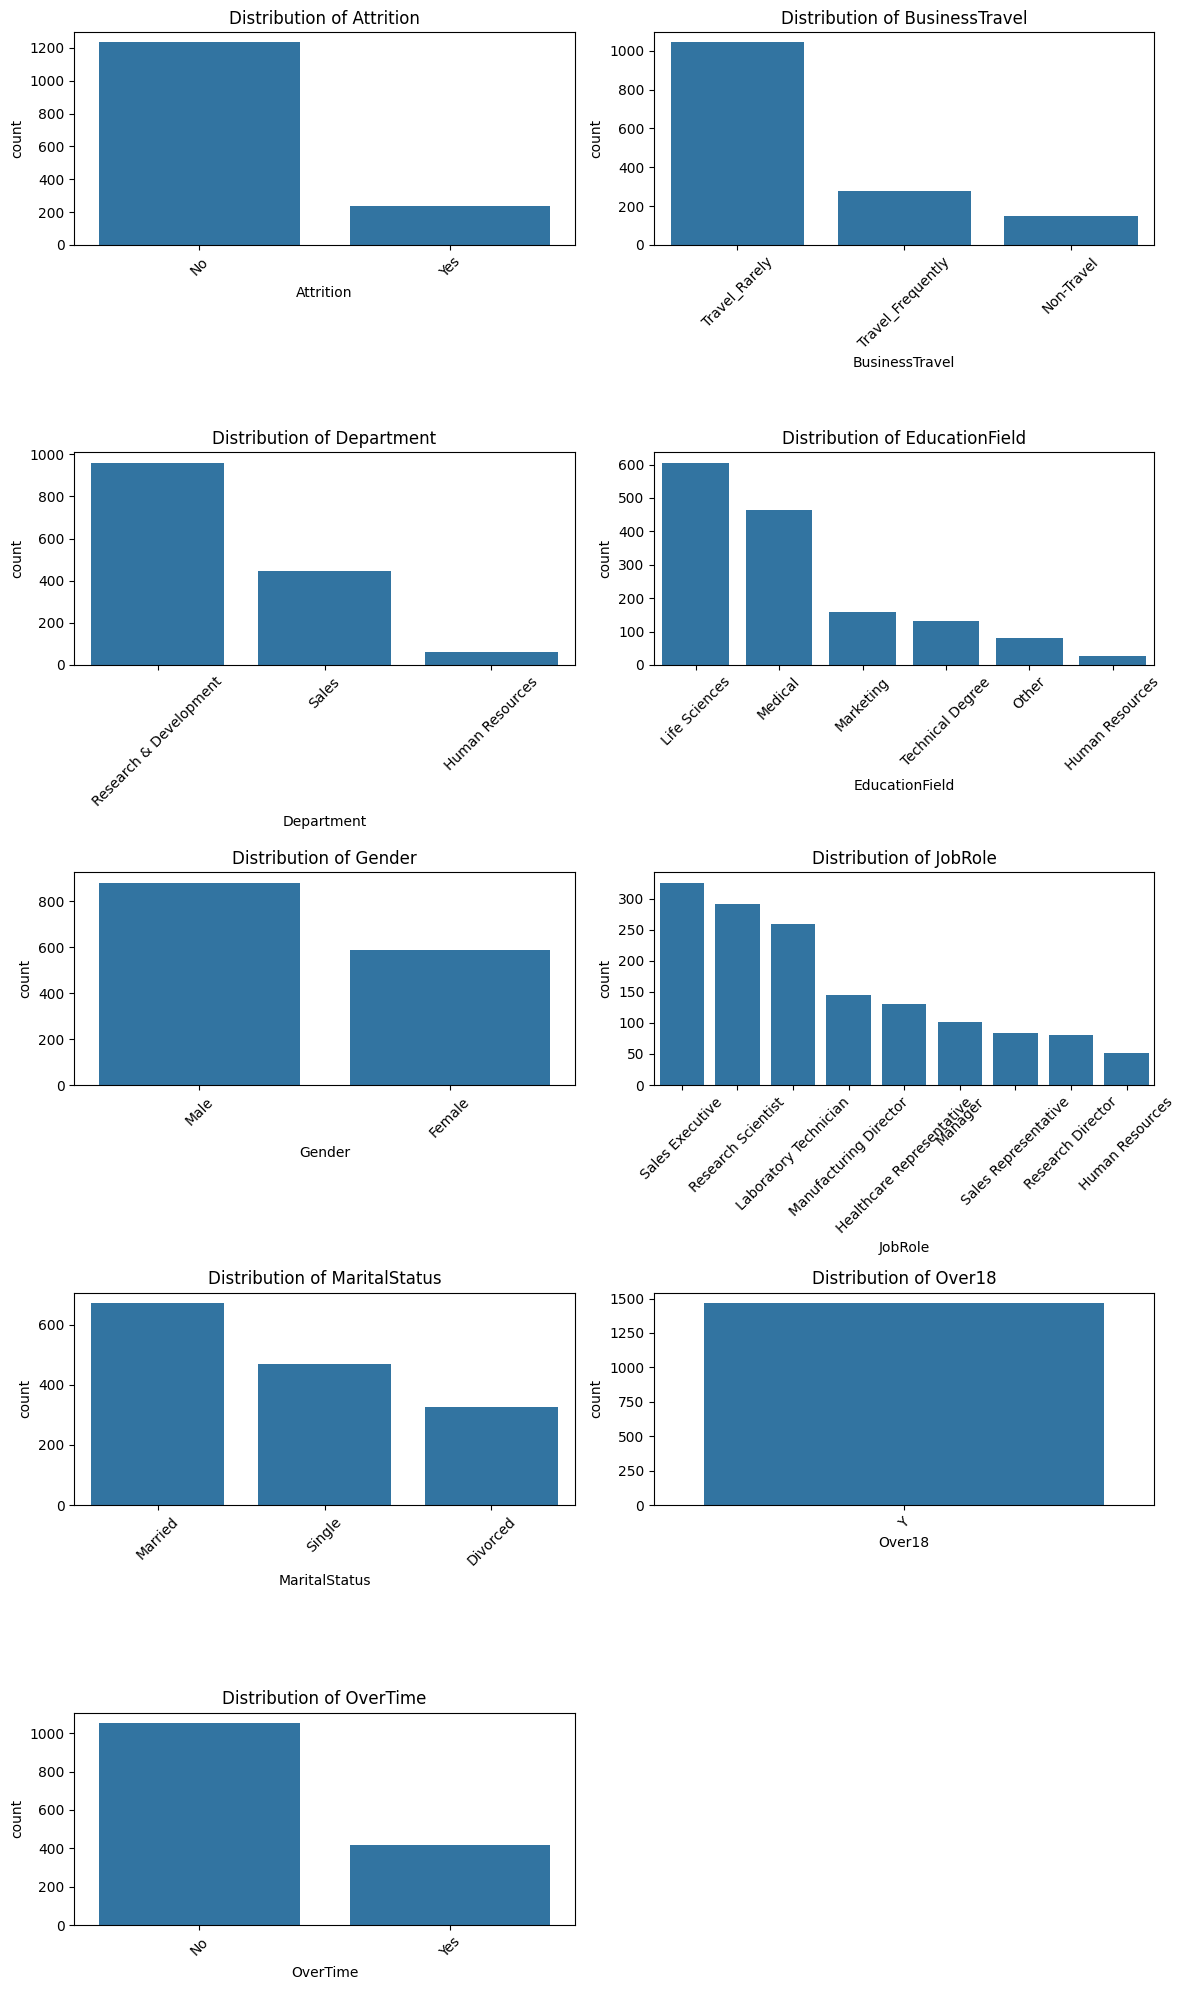

In [54]:
cols_to_plot = cat_cols

n_cols = 2
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, ax=axes[i], order=order)
    axes[i].set_title(f"Distribution of {col}")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [55]:
num_cols = df.select_dtypes(exclude=["object"]).columns
len(num_cols)

26

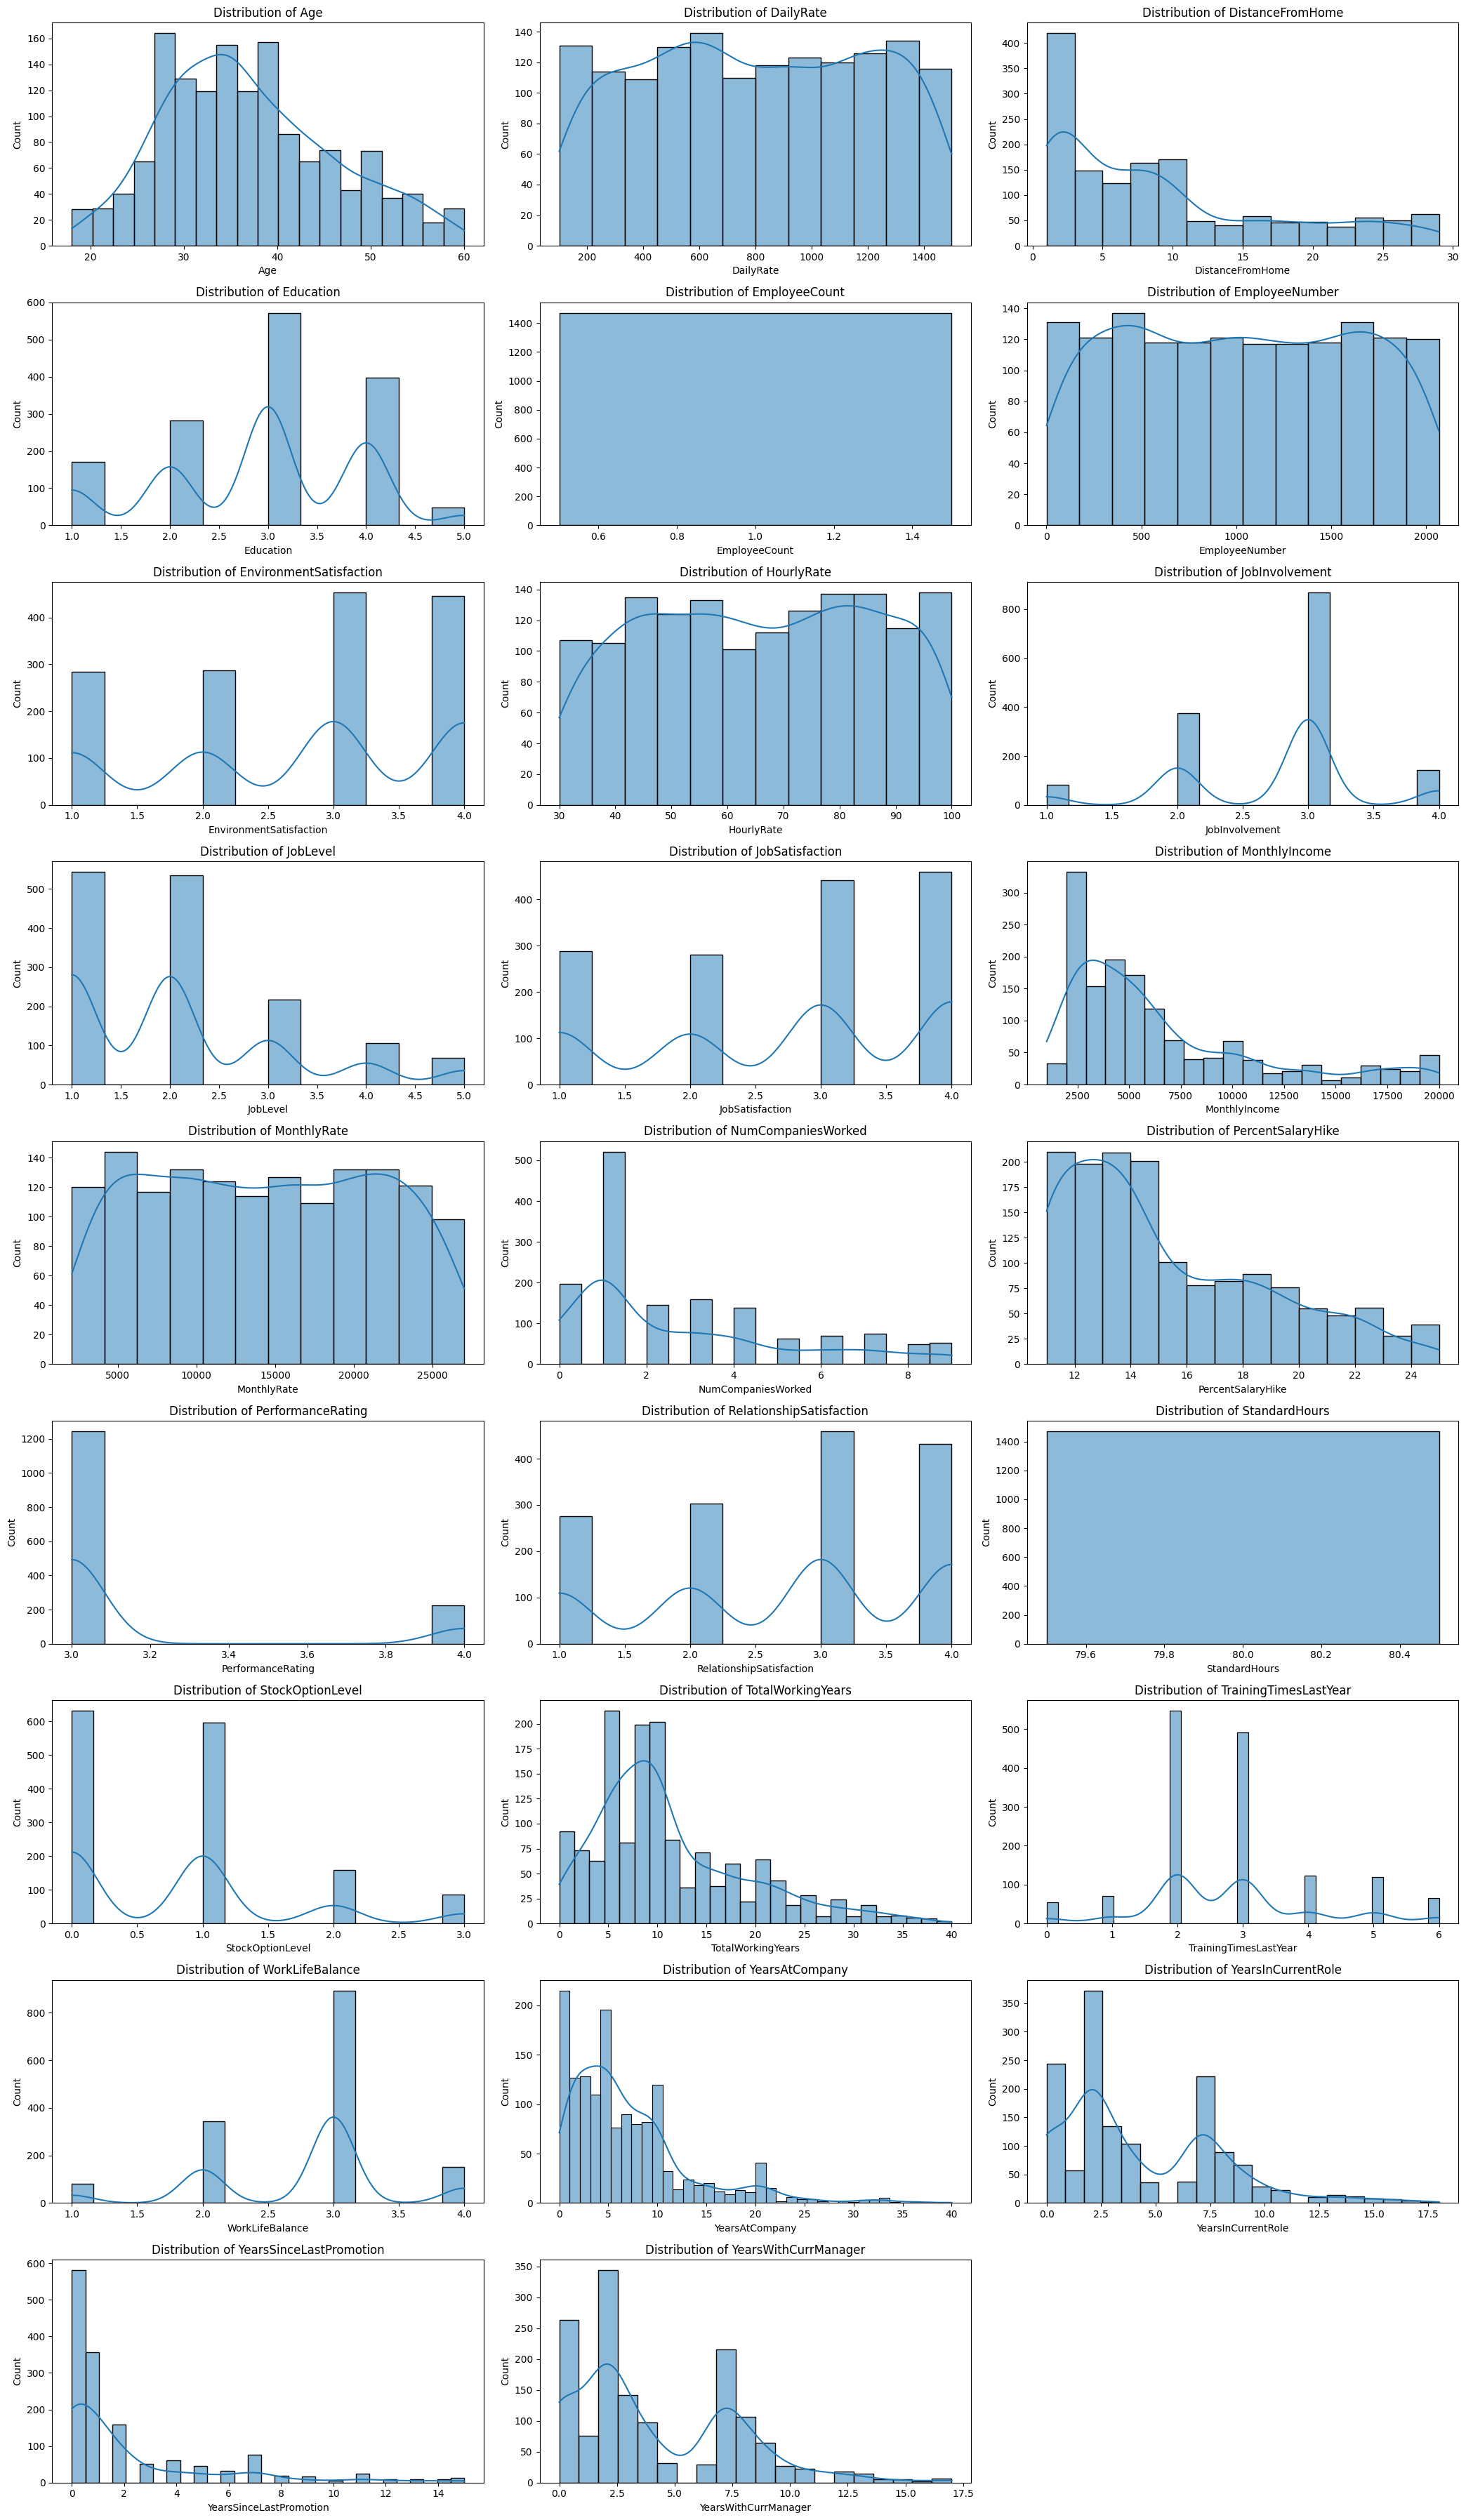

In [56]:
max_plots = 26
cols_to_plot = num_cols[:max_plots]

n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

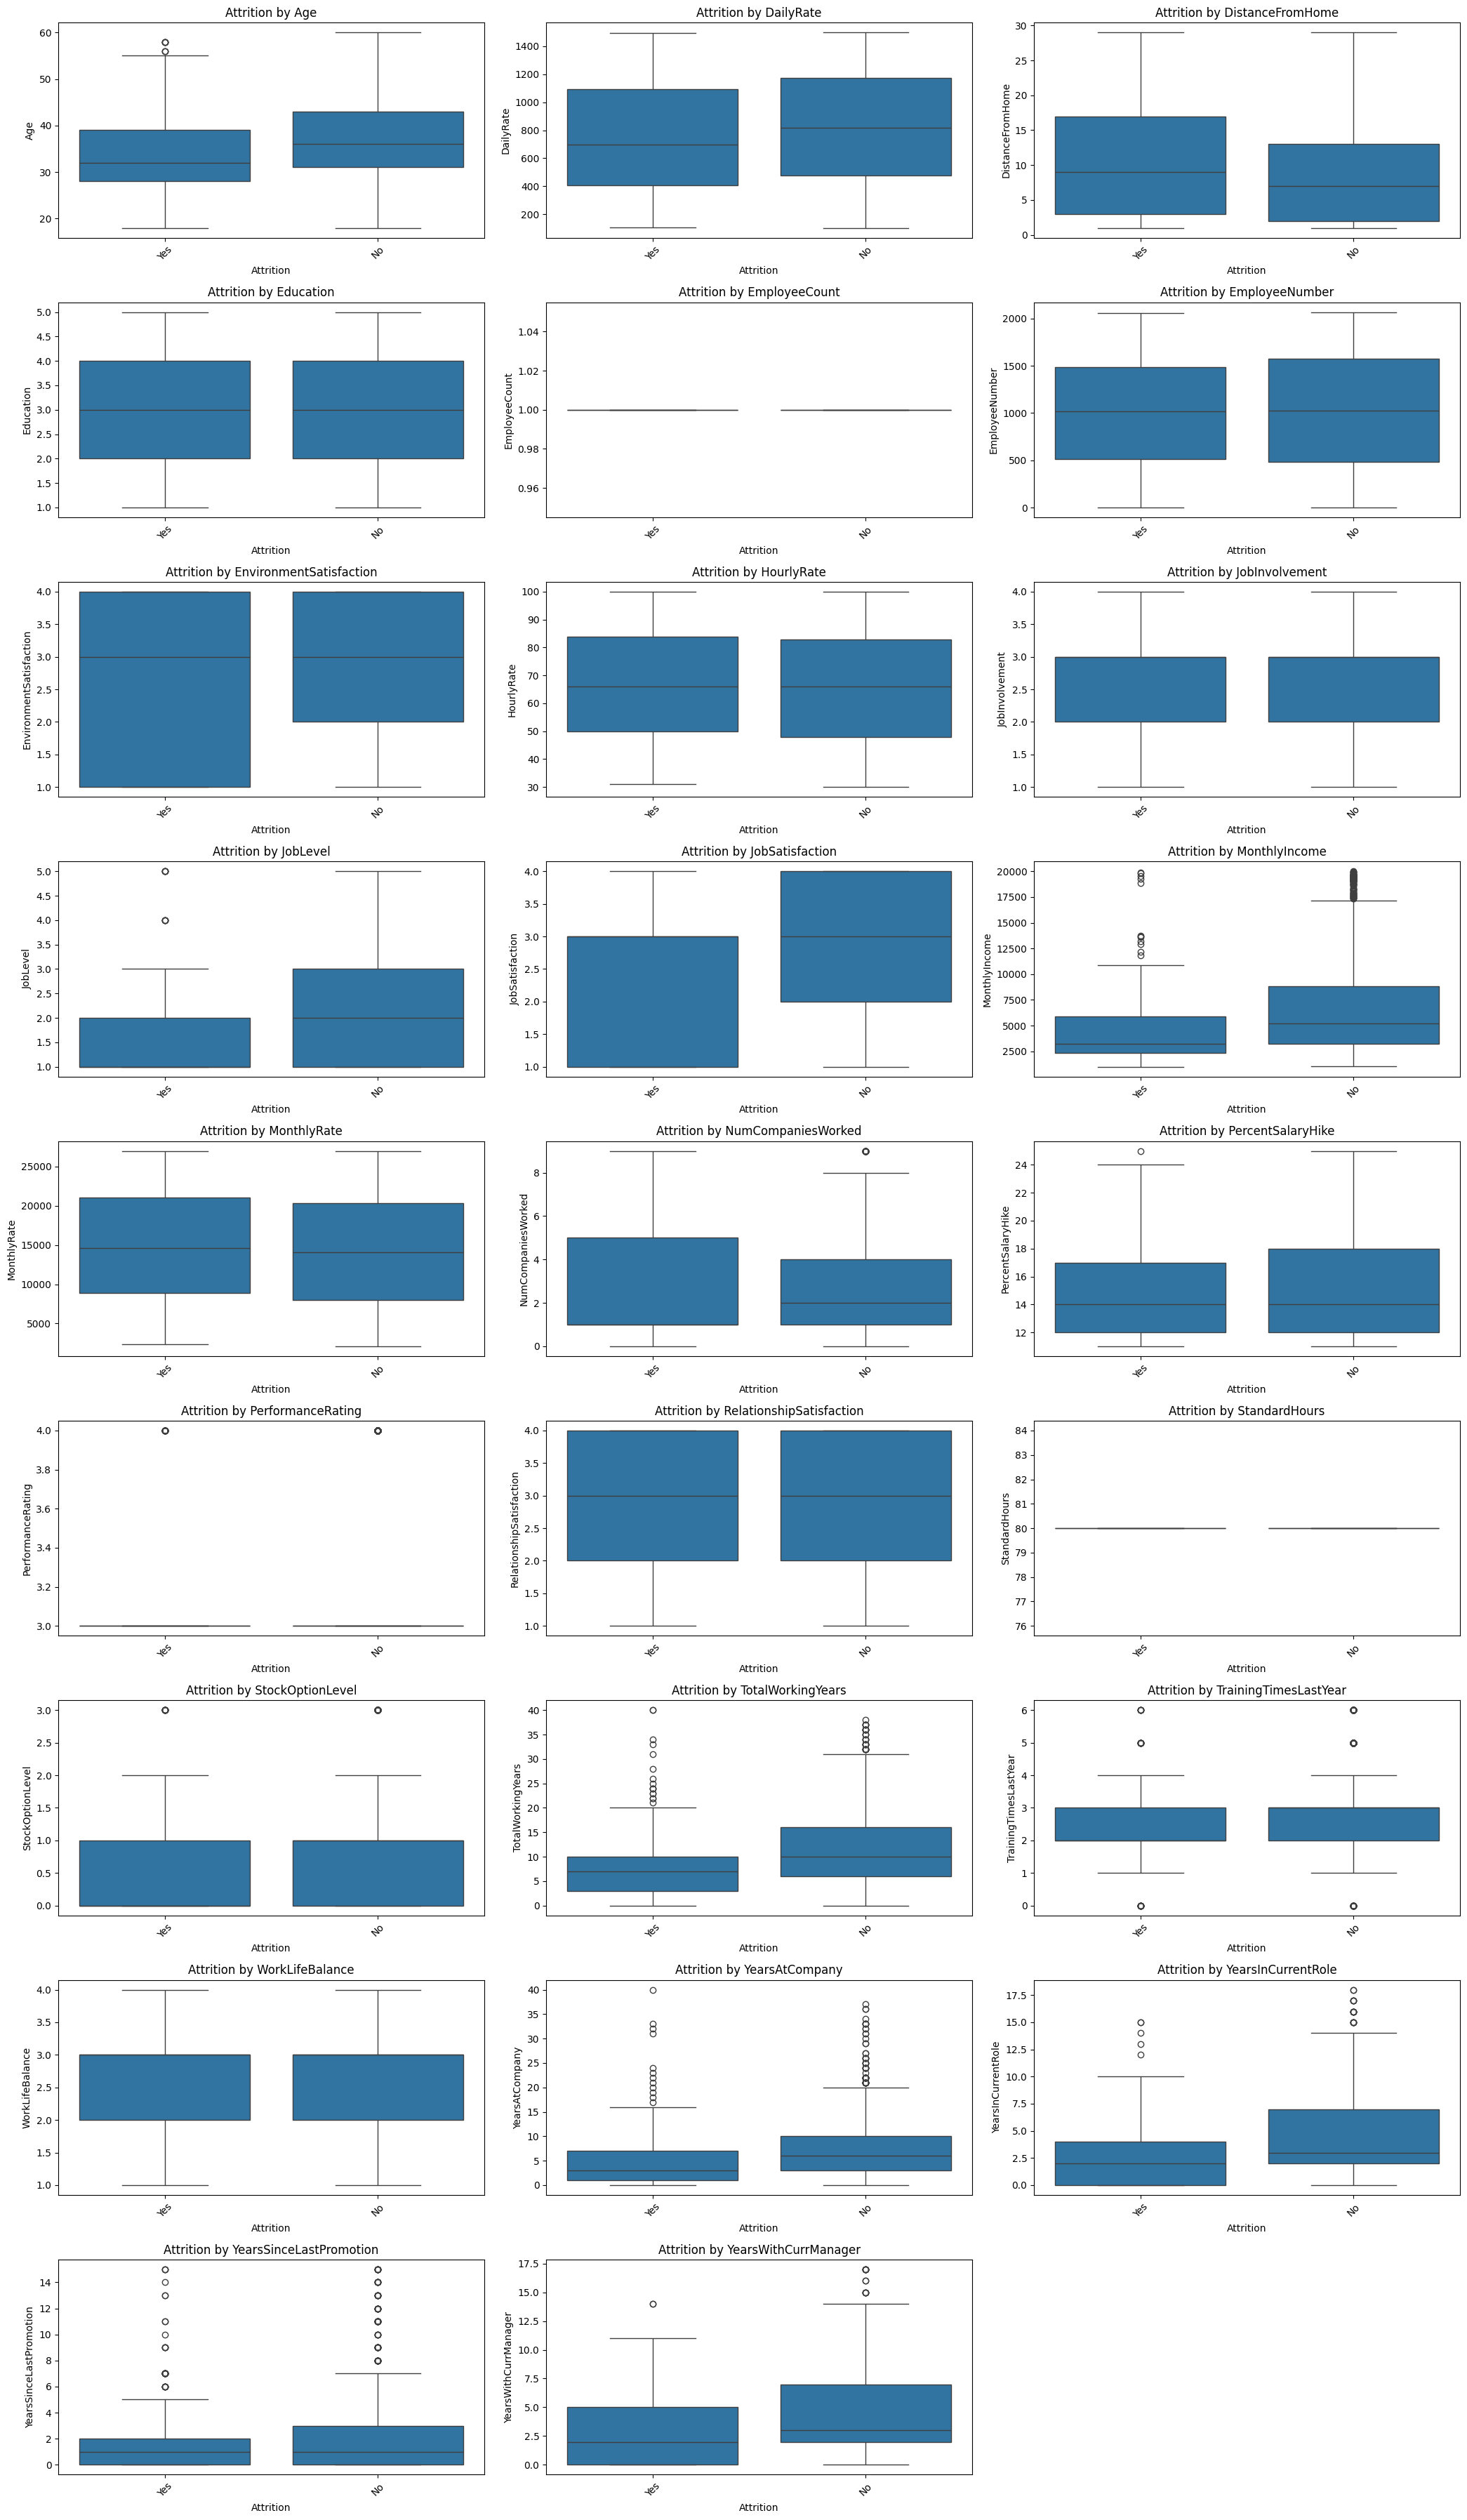

In [57]:
max_plots = 26
cols_to_plot = num_cols[:max_plots]

n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 7, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x='Attrition', y=col, data=df,ax=axes[i])
    axes[i].set_title(f"Attrition by {col}")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(len(cols_to_plot), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

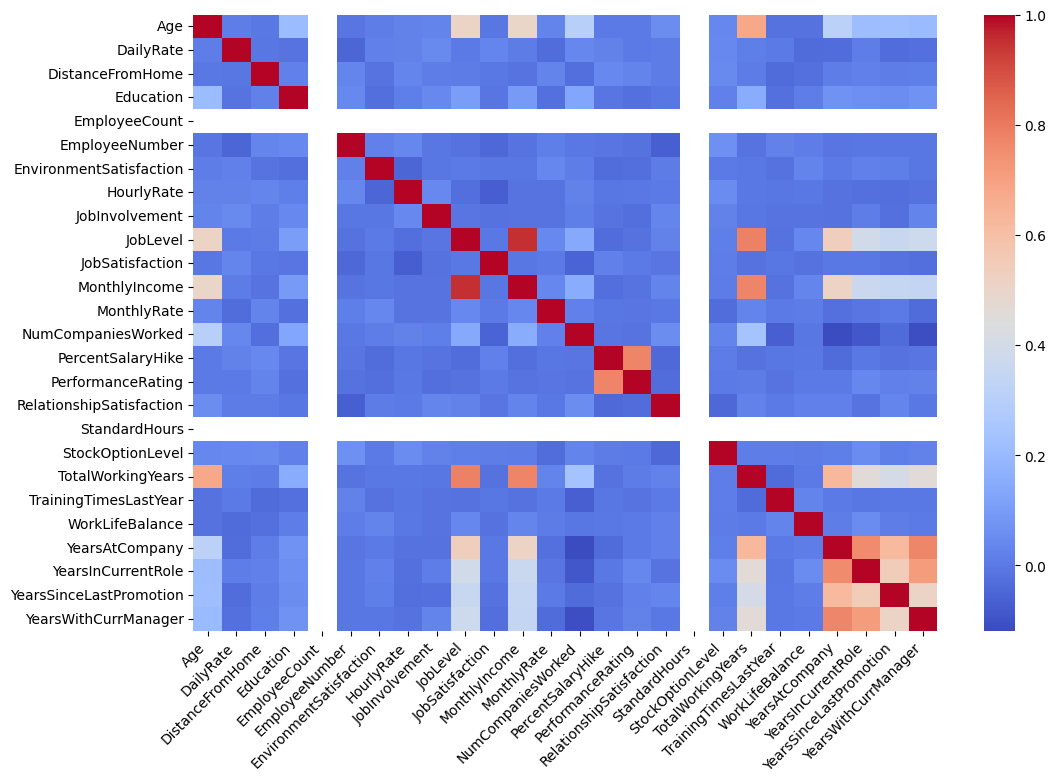

In [273]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.select_dtypes(exclude=['object']).corr(), cmap='coolwarm')

plt.xticks(rotation=45, ha='right')  
plt.yticks(rotation=0)               

plt.show()

## **Why use PCA & PLS-DA?**

**1. Multicollinearity**

Correlation analysis reveals that several variables, particularly those related to employee tenure and compensation, are highly correlated. This indicates the presence of multicollinearity, which makes traditional regression approaches less suitable. Therefore, PCA and PLS are appropriate methods as they can effectively handle correlated predictors by extracting latent variables.

**2. High-dimensional & structured data**

The dataset contains multiple interrelated features describing employee characteristics, making it suitable for dimensionality reduction techniques such as PCA, which can uncover underlying structure in the data.

**3. Suitability of PLS for supervised problem**

Since the objective is to understand and model employee attrition, PLS is particularly suitable as it maximizes the covariance between predictor variables and the response variable, allowing for the identification of key drivers of attrition.

## **Analysis of EDA:**
- No missing values or duplicate values found. Safe to use PCA & PLS.
- The target variable Attrition is imbalanced, with a significantly higher number of employees who did not leave. However, since PCA is an unsupervised method and PLS focuses on covariance rather than classification accuracy, no resampling techniques were applied.
- The distribution of some columns such as YearsAtCompany are right-skewed, which reflect the natural structure of workforce data where most employees have relatively short tenure. Since PCA and PLS do not require normality assumptions, no transformation was applied. All variables will be mean-centered prior to analysis.
- Several groups of variables, particularly those related to tenure, exhibit strong correlations, indicating the presence of multicollinearity.
- Columns that can be removed： EmployeeCount, StandardHours, EmployeeNumber
- Boxplots were used to provide an initial comparison of numerical variables across attrition groups. While some variables show limited individual differences, this analysis provides intuitive insights that complement the subsequent multivariate analysis using PLS, which captures the combined effects of multiple variables.

# Data Preprocessing

In [145]:
# drop constant columns & columns with no meaning
df = df.loc[:, df.nunique()>1]
df=df.drop(columns=['EmployeeNumber'])

In [146]:
# convert target variable to 1/0
df['Attrition']=df['Attrition'].map({'Yes':1, 'No':0})

In [147]:
cat_cols_2=df.select_dtypes(include='object').columns
df_encoded=pd.get_dummies(df,columns=cat_cols_2)

In [148]:
Y=df_encoded['Attrition']
X=df_encoded.drop(columns=['Attrition'])
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Female,Gender_Male,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,OverTime_No,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True
1,49,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False
2,37,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,False,True,False,True,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,True
3,33,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,False,True,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True
4,27,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,False,True,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,12290,4,17,3,3,1,17,3,3,5,2,0,3,False,True,False,False,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,True,False
1466,39,613,6,1,4,42,2,3,1,9991,21457,4,15,3,1,1,9,5,3,7,7,1,7,False,False,True,False,True,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,True,False
1467,27,155,4,3,2,87,4,2,2,6142,5174,1,20,4,2,1,6,0,3,6,2,0,3,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True
1468,49,1023,2,3,4,63,2,2,2,5390,13243,2,14,3,4,0,17,3,2,9,6,0,8,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,True,False


# PCA

In [149]:
X_scaled = (X - X.mean())/X.std()

In [150]:
XtX=np.matmul(X_scaled.transpose(),X_scaled)

In [151]:
from sklearn.decomposition import PCA

pca = PCA()
scores = pca.fit_transform(X_scaled)

In [152]:
explained_variance = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained_variance)

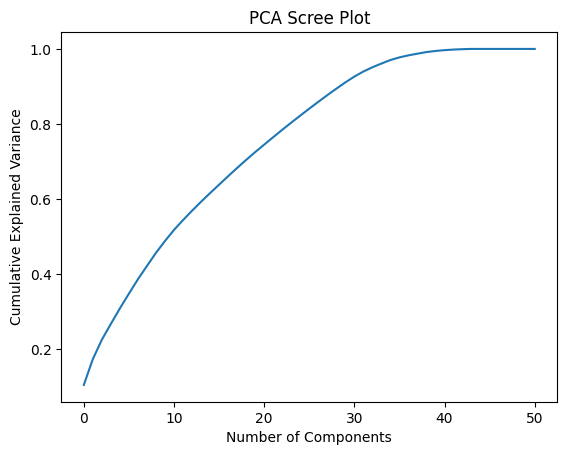

In [67]:
plt.plot(cum_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.show()

In [68]:
t1 = scores[:, 0]
t2 = scores[:, 1]
t3 = scores[:, 2]

In [69]:
import numpy as np
from matplotlib.patches import Ellipse
import scipy.stats as stats

def plot_ellipse(x, y, ax, confidence=0.95, edgecolor='red'):
    cov = np.cov(x, y)
    mean = [np.mean(x), np.mean(y)]
    
    chi2_val = stats.chi2.ppf(confidence, df=2)
    
    eigvals, eigvecs = np.linalg.eigh(cov)
    
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    
    angle = np.degrees(np.arctan2(*eigvecs[:,0][::-1]))
    
    width, height = 2 * np.sqrt(eigvals * chi2_val)
    
    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        edgecolor=edgecolor,
        fc='none',
        linestyle='--'
    )
    
    ax.add_patch(ellipse)

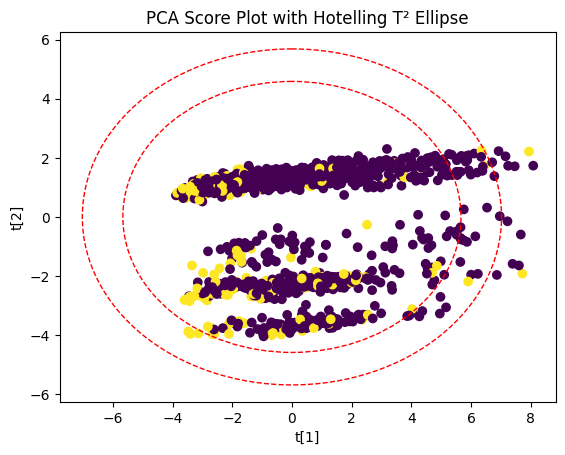

In [70]:
fig, ax = plt.subplots()

ax.scatter(t1, t2, c=Y)

# 95%
plot_ellipse(t1, t2, ax, confidence=0.95, edgecolor='red')

# 99%
plot_ellipse(t1, t2, ax, confidence=0.99, edgecolor='red')

plt.xlabel('t[1]')
plt.ylabel('t[2]')
plt.title('PCA Score Plot with Hotelling T² Ellipse')
plt.show()

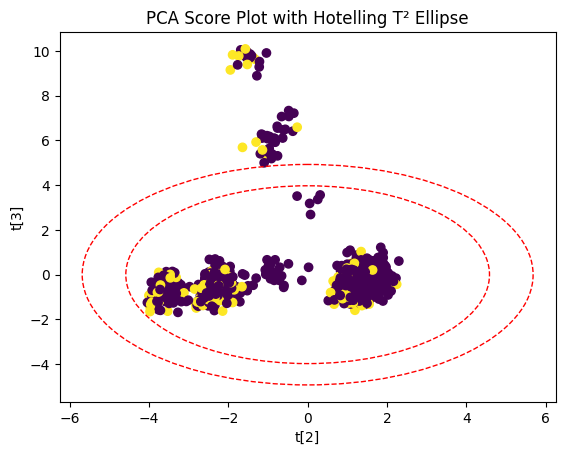

In [71]:
fig, ax = plt.subplots()

ax.scatter(t2, t3, c=Y)

# 95%
plot_ellipse(t2, t3, ax, confidence=0.95, edgecolor='red')

# 99%
plot_ellipse(t2, t3, ax, confidence=0.99, edgecolor='red')

plt.xlabel('t[2]')
plt.ylabel('t[3]')
plt.title('PCA Score Plot with Hotelling T² Ellipse')
plt.show()

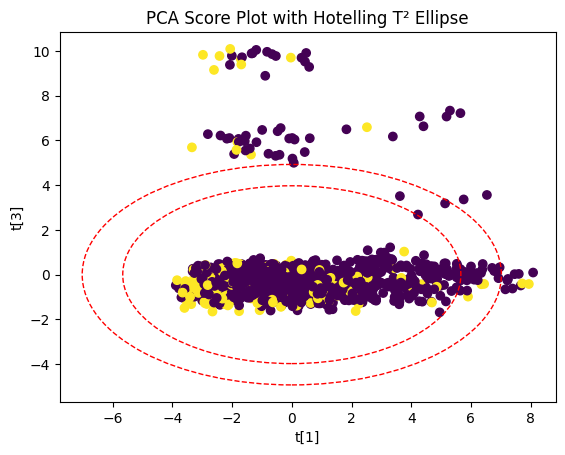

In [72]:
fig, ax = plt.subplots()

ax.scatter(t1, t3, c=Y)

# 95%
plot_ellipse(t1, t3, ax, confidence=0.95, edgecolor='red')

# 99%
plot_ellipse(t1, t3, ax, confidence=0.99, edgecolor='red')

plt.xlabel('t[1]')
plt.ylabel('t[3]')
plt.title('PCA Score Plot with Hotelling T² Ellipse')
plt.show()

**Analysis:**

While the PC1–PC2 and PC1–PC3 projections show some structure, the clearest clustering patterns are observed in the PC2–PC3 score plot.

This indicates that the most prominent segmentation in the dataset is not aligned with the direction of maximum variance (PC1), but rather captured in higher-order components.

## Segmentation（t2 vs t3）

The PC2–PC3 projection reveals the clearest clustering structure.

## Why use PCA in Employment Segmentation

While K-means can directly partition the data into clusters, PCA is essential for understanding the underlying structure of the dataset. PCA helps identify meaningful directions and reduces noise, making clustering more reliable and interpretable.

In this analysis, PCA was first used to reveal clustering patterns and identify the most informative component space (PC2–PC3). K-means was then applied to formally define the clusters for further interpretation.

In [74]:
X_cluster = scores[:, [1, 2]]

In [75]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

In [76]:
df['Cluster'] = clusters

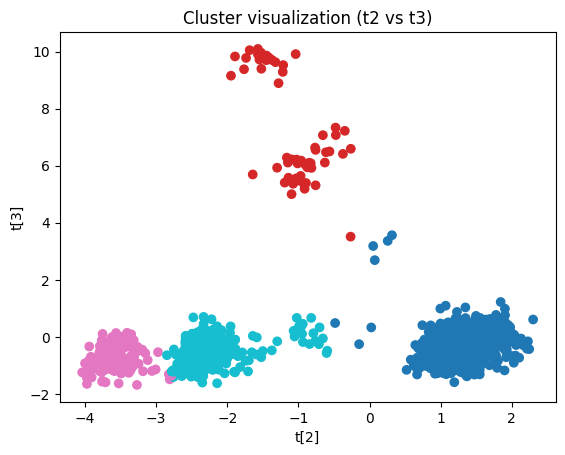

In [77]:
import matplotlib.pyplot as plt

plt.scatter(scores[:,1], scores[:,2], c=clusters, cmap='tab10')
plt.xlabel('t[2]')
plt.ylabel('t[3]')
plt.title('Cluster visualization (t2 vs t3)')
plt.show()

In [78]:
df.groupby('Cluster').mean(numeric_only=True)

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Cluster,,,,,,,,,,,,,,,,,,,,,,,,
0,37.145661,0.137397,806.267562,9.114669,2.898760,2.744835,66.205579,2.743802,1.994835,2.724174,6359.146694,14287.662190,2.737603,15.300620,3.164256,2.707645,0.803719,11.479339,2.791322,2.726240,6.975207,4.182851,2.188017,4.113636
1,37.033898,0.203390,749.610169,8.915254,2.966102,2.677966,63.237288,2.728814,1.864407,2.610169,5946.677966,13611.322034,2.983051,14.796610,3.135593,2.915254,0.796610,10.271186,2.559322,2.915254,6.152542,3.372881,1.491525,3.389831
2,36.591837,0.238095,732.979592,10.108844,3.122449,2.748299,66.598639,2.700680,2.122449,2.653061,6254.095238,14152.333333,2.442177,14.816327,3.122449,2.673469,0.836735,10.108844,2.734694,2.795918,6.442177,4.170068,2.095238,4.061224
3,36.341216,0.192568,835.175676,9.047297,2.844595,2.641892,65.040541,2.699324,2.300676,2.804054,7207.597973,14616.027027,2.614865,15.189189,3.138514,2.706081,0.739865,11.408784,2.905405,2.827703,7.567568,4.581081,2.371622,4.331081


In [79]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f'\n===== {col} =====')
    
    result = (
        df.groupby('Cluster')[col]
        .value_counts(normalize=True)
        .unstack()
        .round(2)
    )
    §
    print(result)


===== BusinessTravel =====
BusinessTravel  Non-Travel  Travel_Frequently  Travel_Rarely
Cluster                                                     
0                     0.10               0.19           0.71
1                     0.10               0.17           0.73
2                     0.08               0.20           0.72
3                     0.11               0.18           0.70

===== Department =====
Department  Human Resources  Research & Development  Sales
Cluster                                                   
0                       0.0                    0.99    0.0
1                       1.0                     NaN    NaN
2                       NaN                     NaN    1.0
3                       NaN                     NaN    1.0

===== EducationField =====
EducationField  Human Resources  Life Sciences  Marketing  Medical  Other  \
Cluster                                                                     
0                           NaN           0.46

In [80]:
df.groupby('Cluster')['Attrition'].value_counts(normalize=True)

Cluster  Attrition
0        0            0.862603
         1            0.137397
1        0            0.796610
         1            0.203390
2        0            0.761905
         1            0.238095
3        0            0.807432
         1            0.192568
Name: proportion, dtype: float64

In [91]:
df.groupby('OverTime')['Attrition'].mean()

OverTime
No     0.104364
Yes    0.305288
Name: Attrition, dtype: float64

In [92]:
pd.crosstab(df['OverTime'], df['Attrition'], normalize='index')

Attrition,0,1
OverTime,,
No,0.895636,0.104364
Yes,0.694712,0.305288


**Analysis:**

PC1 不代表 segmentation： Although PC1 captures the largest variance, it does not necessarily represent meaningful group separation. In this case, clearer clustering patterns emerge in PC2–PC3, indicating that segmentation is driven by secondary variance components rather than the dominant variance direction.

PCA-based clustering identifies four distinct employee segments with different workforce characteristics and attrition patterns.

Cluster 0 (R&D – Well-Paid Technical Group) consists primarily of R&D employees with relatively lower job levels but competitive compensation and higher salary increases. Despite having the second-highest overtime among the clusters, this group exhibits the lowest attrition rate. This suggests that strong compensation may help offset workload pressure and contribute to employee retention in technical roles.

Cluster 1 (HR – Junior, Low-Compensation Group) is composed mainly of Human Resources employees at relatively junior levels with lower compensation. Although this group reports relatively high relationship satisfaction and recent promotions, it still shows moderately high attrition. This indicates that compensation may be a more critical factor influencing turnover than short-term satisfaction or promotion signals.

Cluster 2 (Sales Executive – High-Risk, High-Pressure Group) consists primarily of Sales Executives, many with marketing-related backgrounds and relatively high education levels. This group exhibits the highest attrition rate, along with the highest overtime and frequent travel. While job level is moderate, overall compensation is not proportionally high, suggesting that the combination of high workload and insufficient compensation may drive higher turnover in this segment.

Cluster 3 (Sales – Experienced, Cross-Disciplinary Group) includes Sales employees with more diverse backgrounds, such as medical or life sciences. This group has the highest job level, income, job satisfaction, tenure, and salary increases. Although overtime remains relatively high, its attrition rate is lower than Cluster 2, suggesting that higher compensation and seniority may help mitigate the impact of workload.

Supporting this, overall analysis shows that employees working overtime have nearly three times the attrition rate compared to those who do not (30.5% vs. 10.4%), indicating a strong association between workload and turnover.

Overall, the findings suggest that attrition drivers vary across segments:

In technical roles, compensation may offset workload pressure
In HR roles, low compensation appears to be a key risk factor
In sales roles, high workload combined with relatively lower compensation drives higher attrition
Higher seniority and compensation may partially mitigate attrition risk even under high workload

These results highlight the importance of designing targeted retention strategies for different employee segments, rather than applying a uniform approach.

## Outlier Analysis（t1 vs t3）

Outliers are identified based on the Hotelling’s T² ellipse.

In [101]:
T = np.vstack([t1, t3]).T

In [102]:
cov = np.cov(T, rowvar=False)
inv_cov = np.linalg.inv(cov)
mean = np.mean(T, axis=0)

T2 = []

for i in range(len(T)):
    diff = T[i] - mean
    T2.append(diff.T @ inv_cov @ diff)

T2 = np.array(T2)

In [103]:
threshold_99 = stats.chi2.ppf(0.99, df=2)

In [104]:
outliers = np.where(T2 > threshold_99)[0]

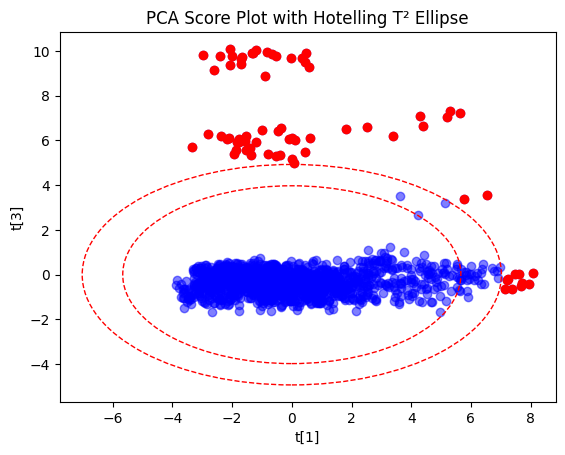

In [105]:
fig, ax = plt.subplots()

ax.scatter(t1, t3, c='blue', alpha=0.5)
ax.scatter(t1[outliers], t3[outliers], c='red', label='Outliers')


# 95%
plot_ellipse(t1, t3, ax, confidence=0.95, edgecolor='red')

# 99%
plot_ellipse(t1, t3, ax, confidence=0.99, edgecolor='red')

plt.xlabel('t[1]')
plt.ylabel('t[3]')
plt.title('PCA Score Plot with Hotelling T² Ellipse')
plt.show()

In [107]:
df_outliers = df.iloc[outliers]
df_outliers.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,39.585714,0.200000,728.157143,8.085714,3.000000,2.614286,63.328571,2.700000,2.328571,2.557143,7945.842857,14247.628571,2.985714,14.985714,3.157143,2.885714,0.742857,13.885714,2.671429,2.900000,10.400000,4.742857,2.857143,4.642857,1.000000
std,10.177402,0.402888,418.339701,7.946821,0.992727,1.053536,20.321846,0.729304,1.585454,1.085287,6730.445924,7647.741345,2.916683,3.774410,0.366563,1.029181,0.845889,10.949876,1.270871,0.745032,10.543767,4.326145,4.139893,3.776494,0.589768
min,19.000000,0.000000,106.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1555.000000,2097.000000,0.000000,11.000000,3.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.000000,350.500000,2.000000,2.250000,2.000000,48.500000,2.000000,1.000000,2.000000,2714.750000,7294.250000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,3.000000,3.000000,2.000000,0.000000,2.000000,1.000000
50%,38.000000,0.000000,684.500000,5.500000,3.000000,3.000000,59.500000,3.000000,2.000000,2.500000,4713.000000,13926.500000,1.500000,14.000000,3.000000,3.000000,1.000000,10.000000,2.500000,3.000000,5.500000,3.000000,1.000000,4.000000,1.000000
75%,46.000000,0.000000,1110.750000,10.000000,4.000000,3.000000,80.750000,3.000000,3.750000,3.750000,13200.750000,21378.750000,4.000000,17.750000,3.000000,4.000000,1.000000,21.750000,3.000000,3.000000,10.750000,7.000000,3.750000,7.750000,1.000000
max,60.000000,1.000000,1444.000000,26.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26894.000000,9.000000,24.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,36.000000,18.000000,15.000000,15.000000,3.000000


In [108]:
df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Cluster
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,0.161224,802.485714,9.192517,2.912925,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,0.844218
std,9.135373,0.367863,403.509100,8.106864,1.024165,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,1.241260
min,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,0.000000,465.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.000000
50%,36.000000,0.000000,802.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,0.000000
75%,43.000000,0.000000,1157.000000,14.000000,4.000000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,2.000000
max,60.000000,1.000000,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,3.000000


In [109]:
num_cols = df.select_dtypes(exclude='object').columns

diff = (df_outliers[num_cols].mean() - df[num_cols].mean())\
        .sort_values(ascending=False)

diff

MonthlyIncome               1442.911565
YearsAtCompany                 3.391837
Age                            2.661905
TotalWorkingYears              2.606122
YearsSinceLastPromotion        0.669388
YearsWithCurrManager           0.519728
YearsInCurrentRole             0.513605
NumCompaniesWorked             0.292517
JobLevel                       0.264626
RelationshipSatisfaction       0.173469
Cluster                        0.155782
WorkLifeBalance                0.138776
Education                      0.087075
Attrition                      0.038776
PerformanceRating              0.003401
JobInvolvement                -0.029932
StockOptionLevel              -0.051020
EnvironmentSatisfaction       -0.107483
TrainingTimesLastYear         -0.127891
JobSatisfaction               -0.171429
PercentSalaryHike             -0.223810
DistanceFromHome              -1.106803
HourlyRate                    -2.562585
MonthlyRate                  -65.474830
DailyRate                    -74.328571


In [110]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f'\n===== {col} =====')
    
    outliers = (
        df_outliers[col]
        .value_counts(normalize=True)
        .round(2)
    )
    all = (
        df[col]
        .value_counts(normalize=True)
        .round(2)
    )
    
    result=(outliers - all).sort_values(ascending=False)
    
    print(result)


===== BusinessTravel =====
BusinessTravel
Travel_Rarely        0.02
Non-Travel           0.00
Travel_Frequently   -0.02
Name: proportion, dtype: float64

===== Department =====
Department
Human Resources           0.82
Sales                    -0.23
Research & Development   -0.58
Name: proportion, dtype: float64

===== EducationField =====
EducationField
Human Resources     0.37
Other              -0.02
Technical Degree   -0.03
Marketing          -0.07
Life Sciences      -0.12
Medical            -0.13
Name: proportion, dtype: float64

===== Gender =====
Gender
Male      0.09
Female   -0.09
Name: proportion, dtype: float64

===== JobRole =====
JobRole
Human Resources              0.70
Manager                      0.16
Research Director           -0.02
Healthcare Representative     NaN
Laboratory Technician         NaN
Manufacturing Director        NaN
Research Scientist            NaN
Sales Executive               NaN
Sales Representative          NaN
Name: proportion, dtype: float64



In [111]:
df['Attrition'].value_counts(normalize=True)

Attrition
0    0.838776
1    0.161224
Name: proportion, dtype: float64

In [112]:
df_outliers['Attrition'].value_counts(normalize=True)

Attrition
0    0.8
1    0.2
Name: proportion, dtype: float64

**Analysis**:

Outlier analysis reveals that these observations are not random anomalies, but represent a distinct subgroup of employees.

These individuals are predominantly from the Human Resources department, often in managerial roles, with significantly higher income, longer tenure, and greater overall experience.

Interestingly, despite their higher compensation and seniority, this group shows slightly lower satisfaction levels, suggesting that factors beyond compensation—such as role-specific challenges or organizational dynamics—may influence their experience.

This highlights the value of PCA-based outlier detection in identifying meaningful but rare employee segments that may require different management strategies.

Outlier analysis shows that these employees have a moderately higher attrition rate (20%) compared to the overall population (16%).

Although this group consists of more senior and higher-paid employees, their attrition is not lower as might be expected.

Combined with earlier findings of lower satisfaction levels, this suggests that compensation alone may not be sufficient to retain employees in these roles, and other factors such as role-specific challenges or organizational dynamics may contribute to turnover.

## PLS

if have time, compared with other ML models

In [159]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.cross_decomposition import PLSRegression
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

components = list(range(1, 11))
scores = []

for n in components:
    pls = PLSRegression(n_components=n)

    score = cross_val_score(
        pls,
        X_scaled,
        Y,
        cv=skf,
        scoring='neg_mean_squared_error'
    ).mean()

    scores.append(score)

best_n = components[np.argmax(scores)]
print("Best n_components:", best_n)

Best n_components: 4


In [160]:
from sklearn.cross_decomposition import PLSRegression

pls = PLSRegression(n_components=4)
pls.fit(X_scaled, Y)

PLSRegression(n_components=4)

In [161]:
coef = pd.Series(pls.coef_.flatten(), index=X.columns)
coef.sort_values(key=abs, ascending=False).head(15)

OverTime_Yes                        0.046663
OverTime_No                        -0.046663
EnvironmentSatisfaction            -0.045730
JobInvolvement                     -0.045149
JobSatisfaction                    -0.043210
NumCompaniesWorked                  0.036401
YearsSinceLastPromotion             0.032582
JobRole_Sales Representative        0.031304
DistanceFromHome                    0.029678
BusinessTravel_Travel_Frequently    0.028989
JobRole_Laboratory Technician       0.028670
MaritalStatus_Single                0.028375
Age                                -0.028365
BusinessTravel_Non-Travel          -0.026165
RelationshipSatisfaction           -0.024564
dtype: float64

In [162]:
def calculate_vip(X, y, pls_model):
    t = pls_model.x_scores_
    w = pls_model.x_weights_
    q = pls_model.y_loadings_.flatten()  

    p, h = w.shape

    s = np.sum((t**2) * (q**2), axis=0)

    total_s = np.sum(s)

    vip = np.sqrt(p * (w**2 @ s) / total_s)

    return vip

In [163]:
vip = calculate_vip(X_scaled, Y.values.reshape(-1,1), pls)

vip_series = pd.Series(vip, index=X.columns)

vip_series.sort_values(ascending=False).head(15)

OverTime_Yes                    2.169407
OverTime_No                     2.169407
TotalWorkingYears               1.727996
JobLevel                        1.696120
MonthlyIncome                   1.670051
YearsAtCompany                  1.557743
YearsInCurrentRole              1.434514
MaritalStatus_Single            1.433326
YearsWithCurrManager            1.400624
Age                             1.382676
YearsSinceLastPromotion         1.380145
JobInvolvement                  1.290063
JobRole_Sales Representative    1.247123
EnvironmentSatisfaction         1.178413
StockOptionLevel                1.177928
dtype: float64

**Analysis:**

Using PLS analysis, I identified key drivers of employee attrition.

Overtime emerged as the most significant factor, with employees working overtime showing substantially higher attrition rates.

In addition, tenure-related variables such as total working years and years at the company were also important, indicating that employee career stage plays a role in turnover.

Compensation-related factors, including job level and income, were also influential, although not sufficient on their own to explain attrition.

## Attrition Prediction（PLS-DA）

In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42
)

In [165]:
pls = PLSRegression(n_components=4)
pls.fit(X_train, y_train)

PLSRegression(n_components=4)

In [166]:
y_pred = pls.predict(X_test)

y_pred_class = (y_pred > 0.4).astype(int)

In [167]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_score(y_test, y_pred_class)
print(classification_report(y_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       255
           1       0.55      0.44      0.49        39

    accuracy                           0.88       294
   macro avg       0.73      0.69      0.71       294
weighted avg       0.87      0.88      0.87       294



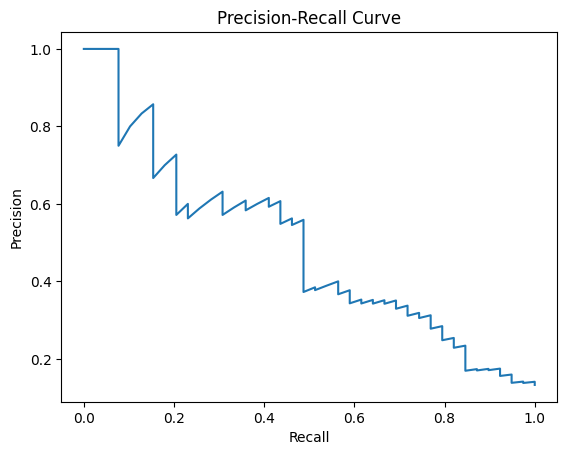

In [168]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [169]:
import numpy as np

f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
print(best_threshold)

0.3982340867345607


## Feature Selection based on VIP & Rebuild the Model

I computed Variable Importance in Projection (VIP) scores and selected features with VIP > 1 to retain the most informative predictors while reducing noise.

I used stratified 5-fold cross-validation on the training set to select the optimal number of latent components, using mean squared error as the evaluation metric.

Since PLS outputs continuous scores rather than probabilities, I tuned the decision threshold using the precision-recall curve on the training data.

I selected a threshold that balances precision and recall, with a focus on improving recall for the minority class.

After tuning, the model significantly improved its ability to identify attrition cases, increasing recall from approximately 0.18 to 0.66.

The improvement in recall came with a decrease in precision, reflecting a trade-off between sensitivity and accuracy.

This trade-off was acceptable given the business context, where identifying at-risk employees is more critical than avoiding false positives.

In [171]:
important_features = vip_series[vip_series > 1].index

In [172]:
X_selected = X[important_features]

In [173]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [174]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.cross_decomposition import PLSRegression
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

components = list(range(1, min(11, X_train.shape[1] + 1)))
scores = []

for n in components:
    pls = PLSRegression(n_components=n)

    score = cross_val_score(
        pls,
        X_train_scaled,
        y_train,
        cv=skf,
        scoring='neg_mean_squared_error'
    ).mean()

    scores.append(score)

best_n = components[np.argmax(scores)]
print("Best n_components:", best_n)
print("CV scores:", scores)

Best n_components: 3
CV scores: [np.float64(-0.11772401384403923), np.float64(-0.11157266310099098), np.float64(-0.11096491593798034), np.float64(-0.11108962750848554), np.float64(-0.11134387556919445), np.float64(-0.11164416601753824), np.float64(-0.11178321271816194), np.float64(-0.11183220682684947), np.float64(-0.11187031462592871), np.float64(-0.11182781054593578)]


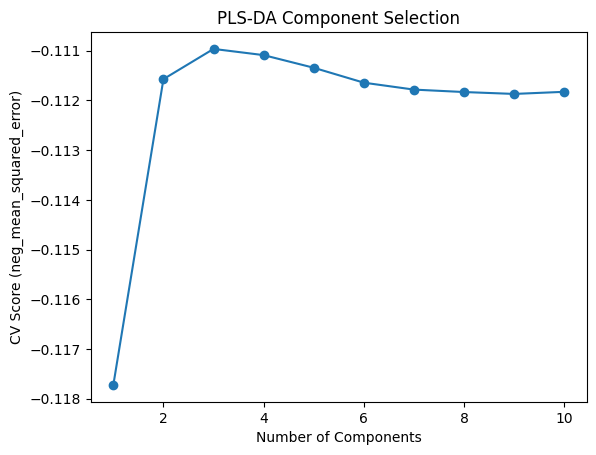

In [175]:
import matplotlib.pyplot as plt

plt.plot(components, scores, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("CV Score (neg_mean_squared_error)")
plt.title("PLS-DA Component Selection")
plt.show()

In [176]:
pls_final = PLSRegression(n_components=best_n)
pls_final.fit(X_train_scaled, y_train)

PLSRegression(n_components=3)

In [177]:
y_score = pls_final.predict(X_test_scaled).ravel()

In [204]:
threshold = 0.29
y_pred = (y_score > threshold).astype(int)

In [205]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.826530612244898
[[212  35]
 [ 16  31]]
              precision    recall  f1-score   support

           0       0.93      0.86      0.89       247
           1       0.47      0.66      0.55        47

    accuracy                           0.83       294
   macro avg       0.70      0.76      0.72       294
weighted avg       0.86      0.83      0.84       294



In [206]:
best_idx = -1
best_precision = 0

for i in range(len(thresholds)):
    if recall[i] >= 0.6 and precision[i] > best_precision:
        best_precision = precision[i]
        best_idx = i

best_threshold = thresholds[best_idx]

print("Threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])

Threshold: 0.29087798735890547
Precision: 0.35294117647058826
Recall: 0.6153846153846154


In [199]:
f1_scores = 2 * (precision * recall) / (precision + recall)
best_idx = np.argmax(f1_scores)

best_threshold = thresholds[best_idx]
print(best_threshold)

0.3982340867345607


**Analysis:**

For prediction, the PLS model achieved high overall accuracy (88%), but showed low recall for employees who left, suggesting that attrition is more difficult to predict and may be influenced by additional unobserved factors.

Precision measures how accurate the positive predictions are, while recall measures how many actual positive cases are captured by the model.

In my model, precision is relatively high (70%), meaning when the model predicts an employee will leave, it is often correct.

However, recall is quite low (18%), which means the model fails to identify most employees who actually leave.

This suggests the model is conservative and biased toward predicting the majority class.

For attrition prediction, recall is more critical because missing employees who are likely to leave can be costly for the organization.

Overall, the results indicate that employee attrition is driven by a combination of workload, career stage, and compensation, and that predictive modeling should account for class imbalance and additional behavioral factors.

## Compared with Other ML Models

In [226]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [208]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight='balanced',  # ⭐处理不平衡
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [209]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]  # 用于PR curve

In [210]:
from sklearn.metrics import classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8469387755102041
              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



In [221]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False)

MonthlyIncome                        0.069722
Age                                  0.061058
TotalWorkingYears                    0.054812
DailyRate                            0.049254
YearsAtCompany                       0.047181
DistanceFromHome                     0.044236
HourlyRate                           0.043322
MonthlyRate                          0.043229
NumCompaniesWorked                   0.037152
YearsWithCurrManager                 0.036964
OverTime_No                          0.032480
StockOptionLevel                     0.030328
PercentSalaryHike                    0.029919
OverTime_Yes                         0.028346
YearsInCurrentRole                   0.028300
EnvironmentSatisfaction              0.027516
JobLevel                             0.024008
JobSatisfaction                      0.023920
YearsSinceLastPromotion              0.021925
WorkLifeBalance                      0.020862
RelationshipSatisfaction             0.020640
TrainingTimesLastYear             

### XGBoost

In [227]:
from xgboost import XGBClassifier

# 计算不平衡比例
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.01,
    scale_pos_weight=scale_pos_weight,  # ⭐关键
    random_state=42,
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [228]:
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [229]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.8469387755102041
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       247
           1       0.53      0.40      0.46        47

    accuracy                           0.85       294
   macro avg       0.71      0.67      0.68       294
weighted avg       0.83      0.85      0.84       294



In [222]:
xgb_importance = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_importance.sort_values(ascending=False)

OverTime_No                          0.050932
TotalWorkingYears                    0.047363
YearsWithCurrManager                 0.039943
JobRole_Research Director            0.039142
StockOptionLevel                     0.039115
JobLevel                             0.037827
EducationField_Marketing             0.035810
Department_Sales                     0.034584
JobRole_Sales Executive              0.028906
NumCompaniesWorked                   0.028489
JobRole_Sales Representative         0.025941
WorkLifeBalance                      0.025602
JobRole_Research Scientist           0.025279
EnvironmentSatisfaction              0.025274
MonthlyIncome                        0.023610
JobSatisfaction                      0.023573
Age                                  0.022968
BusinessTravel_Non-Travel            0.021706
JobInvolvement                       0.021330
YearsAtCompany                       0.020174
YearsSinceLastPromotion              0.019635
DistanceFromHome                  

In [257]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1,0.01],
    'n_estimators': [200, 300, 400,1000]
}

In [258]:
grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',   # ⭐关键（不平衡）
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.03, 0.05, 0.1, 0.01],
                         'max_depth': [3, 4, 5],
                         'n_estimators': [200, 300, 400, 1000]},
             scoring='f1', verbose=1)

In [259]:
best_xgb = grid.best_estimator_
print(grid.best_params_)

{'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 1000}


In [266]:
y_prob = best_xgb.predict_proba(X_test)[:, 1]

threshold = 0.5
y_pred = (y_prob > threshold).astype(int)

In [267]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8299319727891157
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       247
           1       0.46      0.40      0.43        47

    accuracy                           0.83       294
   macro avg       0.68      0.66      0.67       294
weighted avg       0.82      0.83      0.83       294



In [265]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1_scores[best_idx])

Best threshold: 0.5265458
Precision: 0.5588235294117647
Recall: 0.40425531914893614
F1: 0.4691358024204237
